<div style="background:#0f172a; color:white; padding:28px 32px; border-radius:12px; font-family:Arial, sans-serif; border:1px solid #1e293b;">
  <h1 style="margin:0; font-size:30px;">Learning Day 15 — Notebook 3</h1>
  <h2 style="margin:8px 0 0 0; font-size:21px; font-weight:500; color:#dbeafe;">AutoML Limits, SHAP Explainability, Fairness Metrics, and Fairlearn Mitigation</h2>
  <p style="margin:16px 0 0 0; font-size:15px; line-height:1.58; color:#e5e7eb;">This notebook covers the Expert MVD for AutoML with PyCaret. We use an HR Attrition task to show why AutoML is useful but not enough by itself: after the model is trained, a human analyst still needs to check explainability, sensitive features, fairness gaps, and the fairness-performance tradeoff.</p>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">0. Notebook Scope and Learning Goals</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><b>Topic:</b> AutoML with PyCaret — limits, explainability, and fairness.</p>
<p><b>Main idea in simple words:</b> AutoML can quickly build strong models, but it cannot automatically know whether a model is fair, safe, or business-appropriate. That responsibility stays with the analyst.</p>
<p><b>Official Expert MVD tasks covered:</b></p>
<ol>
  <li>Train a PyCaret model on an HR Attrition dataset and analyse it with SHAP / <code>interpret_model()</code>.</li>
  <li>Calculate fairness metrics for <code>Gender</code>: Demographic Parity and Equalized Odds.</li>
  <li>Apply Fairlearn <code>ExponentiatedGradient</code>, compare AUC and fairness metrics, and explain the fairness-performance tradeoff.</li>
</ol>
<p><b>Dataset note:</b> The official MVD mentions IBM HR Analytics from Kaggle. If a local IBM HR CSV is available in <code>data/</code>, the notebook can use it. If it is not available, the notebook creates a realistic HR Attrition proxy dataset so the full workflow remains runnable and transparent.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">1. Coverage Matrix — Expert MVD</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<table style="border-collapse:collapse; width:100%; font-size:14px;">
  <thead>
    <tr style="background:#dbeafe; color:#1e3a8a;">
      <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Requirement</th>
      <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Notebook Section</th>
      <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">How it is covered</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="border:1px solid #bfdbfe; padding:8px;">Train PyCaret model on HR Attrition</td><td style="border:1px solid #bfdbfe; padding:8px;">Sections 6–8</td><td style="border:1px solid #bfdbfe; padding:8px;">PyCaret setup, model comparison, and Random Forest model creation.</td></tr>
    <tr><td style="border:1px solid #bfdbfe; padding:8px;">SHAP / interpret_model</td><td style="border:1px solid #bfdbfe; padding:8px;">Section 9</td><td style="border:1px solid #bfdbfe; padding:8px;">Uses PyCaret <code>interpret_model()</code> and feature importance to inspect model drivers.</td></tr>
    <tr><td style="border:1px solid #bfdbfe; padding:8px;">Discriminatory features</td><td style="border:1px solid #bfdbfe; padding:8px;">Sections 5 and 9</td><td style="border:1px solid #bfdbfe; padding:8px;">Checks Gender attrition rate and explains how SHAP/feature importance can reveal risky features.</td></tr>
    <tr><td style="border:1px solid #bfdbfe; padding:8px;">Demographic Parity and Equalized Odds</td><td style="border:1px solid #bfdbfe; padding:8px;">Section 11</td><td style="border:1px solid #bfdbfe; padding:8px;">Calculates fairness metrics by Gender on holdout predictions.</td></tr>
    <tr><td style="border:1px solid #bfdbfe; padding:8px;">Fairlearn ExponentiatedGradient</td><td style="border:1px solid #bfdbfe; padding:8px;">Sections 12–13</td><td style="border:1px solid #bfdbfe; padding:8px;">Trains a mitigation model and compares performance vs fairness.</td></tr>
    <tr><td style="border:1px solid #bfdbfe; padding:8px;">Fairness-performance tradeoff</td><td style="border:1px solid #bfdbfe; padding:8px;">Sections 14–15</td><td style="border:1px solid #bfdbfe; padding:8px;">Compares AUC, accuracy, and fairness gaps with business interpretation.</td></tr>
  </tbody>
</table>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">2. Simple Theory — Why AutoML Still Needs Human Review</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>Think of AutoML as a fast junior analyst. It can try many models quickly, choose strong candidates, and prepare a pipeline. But it does not understand company policy, legal risk, ethics, or human impact.</p>
<p>In HR Attrition modelling, the model predicts whether an employee may leave. This can help HR plan retention actions, but it can also create risk. If the model treats one gender differently, or uses variables that act as hidden proxies for gender, the model may look accurate but still be unfair.</p>
<p><b>Key idea:</b> Accuracy tells us whether predictions are correct. Fairness tells us whether prediction errors and outcomes are distributed responsibly across groups.</p>
<ul>
  <li><b>SHAP:</b> Explains which features pushed predictions up or down.</li>
  <li><b>Demographic Parity:</b> Checks whether groups receive positive predictions at similar rates.</li>
  <li><b>Equalized Odds:</b> Checks whether model error behavior is similar across groups.</li>
  <li><b>ExponentiatedGradient:</b> Trains a model while trying to satisfy a fairness constraint.</li>
</ul>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #f59e0b; background:#fffbeb; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#92400e; font-size:19px;">Environment Note — No Inline Installation</h3>
    
<p>This notebook checks whether PyCaret, SHAP, and Fairlearn are installed. It does not install packages inside the notebook because inline installation can damage the active kernel.</p>
<p>If a dependency is missing, install it in the same environment outside the notebook, restart the kernel, and run again.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">3. Project Setup — Create Clean Folders</h3>
    
<p>This cell creates the same clean project folder structure used in the approved Day 15 notebooks. Generated files stay out of the main notebook folder.</p>
<ul>
  <li><code>data/</code> stores local or generated datasets.</li>
  <li><code>outputs/charts/</code> stores charts and SHAP images.</li>
  <li><code>outputs/models/</code> stores model-related outputs if needed.</li>
</ul>

  </div>
</div>

In [1]:
# CELL 1 — PROJECT SETUP

# pathlib creates clean relative paths.
from pathlib import Path

# PROJECT_DIR is the folder where this notebook is running.
PROJECT_DIR = Path.cwd()

# DATA_DIR stores input or generated datasets.
DATA_DIR = PROJECT_DIR / "data"

# OUTPUT_DIR stores all notebook outputs.
OUTPUT_DIR = PROJECT_DIR / "outputs"

# CHART_DIR stores chart PNG files and SHAP images.
CHART_DIR = OUTPUT_DIR / "charts"

# MODEL_DIR stores model outputs if needed.
MODEL_DIR = OUTPUT_DIR / "models"

# Create every folder if it does not already exist.
for folder in [DATA_DIR, OUTPUT_DIR, CHART_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Print paths so the user can verify the workflow.
print("Project root:", PROJECT_DIR)
print("Data folder:", DATA_DIR)
print("Chart folder:", CHART_DIR)
print("Model folder:", MODEL_DIR)

Project root: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml
Data folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/data
Chart folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/charts
Model folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/models


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Clean Project Structure Created</h3>
    <p style="margin:8px 0; font-size:15px;">The notebook created a clear local project workflow with separate folders for data, charts, models, and tables. The output confirmed the project root, data folder, chart folder, and model folder were all available inside the Day 15 project structure.</p>
    <p style="margin:8px 0; font-size:15px;">This means later outputs will not be scattered randomly across the main notebook folder. The notebook now has a reproducible place for inputs and saved results.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Data-related files are handled in the <strong>data</strong> folder.</li>
      <li style="margin:5px 0;">Charts are saved in <strong>outputs/charts</strong>.</li>
      <li style="margin:5px 0;">Models are saved in <strong>outputs/models</strong>.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> A clean folder structure matters because AutoML projects can quickly create many artifacts. Separating data, charts, and models makes the work easier to review, submit, and later convert into a production-style workflow.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">4. Import Libraries and Check Dependencies</h3>
    
<p>This cell imports the libraries for PyCaret modelling, SHAP explanation, fairness metrics, and Fairlearn mitigation.</p>
<p><b>Why this matters:</b> Notebook 3 uses more than normal model training. We need PyCaret for AutoML, SHAP for explainability, and Fairlearn for fairness analysis.</p>

  </div>
</div>

In [2]:
# CELL 2 — IMPORT LIBRARIES AND CHECK DEPENDENCIES

# Standard libraries for timing, file handling, and warnings.
import os
import time
import warnings
from contextlib import contextmanager

# Core data libraries.
import numpy as np
import pandas as pd

# Charting library used for professional static charts.
import matplotlib.pyplot as plt

# Scikit-learn tools for the Fairlearn mitigation section.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Hide noisy technical warnings so the notebook stays readable.
warnings.filterwarnings("ignore")

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Core Libraries Imported</h3>
    <p style="margin:8px 0; font-size:15px;">The core Python libraries loaded successfully. These libraries support table handling, numeric work, plotting, modelling, metrics, and notebook display.</p>
    <p style="margin:8px 0; font-size:15px;">There was no error in this import step, so the notebook can continue into PyCaret, SHAP, and fairness analysis without basic Python dependency problems.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;"><strong>pandas</strong> is used for HR data tables.</li>
      <li style="margin:5px 0;"><strong>NumPy</strong> supports numeric calculations.</li>
      <li style="margin:5px 0;"><strong>matplotlib</strong> supports saved charts.</li>
      <li style="margin:5px 0;"><strong>scikit-learn</strong> supports the baseline and fairness comparison models.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> This step prepares the technical foundation. In a real analytics team, this is similar to loading the standard tools before building a repeatable model-risk and fairness workflow.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">5. PyCaret, SHAP, and Fairlearn Dependency Check</h3>
    
<p>This cell checks the specialist libraries. It stops early with a clear message if something is missing.</p>
<p><b>No inline install:</b> This keeps the notebook stable and avoids kernel-breaking installation inside the notebook.</p>

  </div>
</div>

In [3]:
# CELL 3 — CHECK SPECIALIST LIBRARIES

# Track missing packages in one list.
missing_packages = []

# Check PyCaret classification functions.
try:
    import pycaret
    from pycaret.classification import setup, compare_models, create_model
    from pycaret.classification import interpret_model, plot_model
    from pycaret.classification import predict_model, pull
except Exception as error:
    missing_packages.append(f"PyCaret: {error}")

# Check SHAP because PyCaret interpret_model often depends on it.
try:
    import shap
except Exception as error:
    missing_packages.append(f"SHAP: {error}")

# Check Fairlearn metrics and mitigation tools.
try:
    from fairlearn.metrics import MetricFrame
    from fairlearn.metrics import false_positive_rate
    from fairlearn.metrics import selection_rate
    from fairlearn.metrics import true_positive_rate
    from fairlearn.reductions import DemographicParity
    from fairlearn.reductions import ExponentiatedGradient
except Exception as error:
    missing_packages.append(f"Fairlearn: {error}")

# Stop with a readable message if any required package is missing.
if missing_packages:
    raise ImportError("Missing required package(s):\n" + "\n".join(missing_packages))

# Print versions for reproducibility.
print("PyCaret version:", pycaret.__version__)
print("SHAP is ready.")
print("Fairlearn is ready.")
print("Fairness gaps will be calculated manually for Pandas/Fairlearn compatibility.")


PyCaret version: 3.3.2
SHAP is ready.
Fairlearn is ready.
Fairness gaps will be calculated manually for Pandas/Fairlearn compatibility.


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Specialist Libraries Ready</h3>
    <p style="margin:8px 0; font-size:15px;">The output confirmed that <strong>PyCaret version 3.3.2</strong> is available. SHAP is also ready, and Fairlearn is installed.</p>
    <p style="margin:8px 0; font-size:15px;">The notebook also correctly identified that fairness gaps should be calculated manually for Pandas/Fairlearn compatibility. This is important because your local Fairlearn version uses older Pandas logic for some built-in difference functions.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">PyCaret is used for the AutoML model workflow.</li>
      <li style="margin:5px 0;">SHAP is used for explainability.</li>
      <li style="margin:5px 0;">Fairlearn concepts are used for fairness measurement and mitigation.</li>
      <li style="margin:5px 0;">Manual fairness gap calculations avoid the Pandas <strong>level=</strong> compatibility error.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> The environment is usable for the expert topic. The compatibility note is important because it shows responsible engineering: the notebook does not blindly rely on a function that can fail in the user environment.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">6. Helper Functions — Save Charts and Convert Labels</h3>
    
<p>This cell creates two small helper functions used later in the notebook.</p>
<ul>
  <li><code>save_chart()</code> saves polished charts into <code>outputs/charts/</code>.</li>
  <li><code>yes_no_to_binary()</code> converts <code>Yes/No</code> labels into <code>1/0</code> values for fairness metrics.</li>
</ul>

  </div>
</div>

In [4]:
# CELL 4 — HELPER FUNCTIONS

# This helper saves charts with consistent quality.
def save_chart(file_name):
    # Build the full chart path inside outputs/charts.
    chart_path = CHART_DIR / file_name

    # Save the active matplotlib figure.
    plt.savefig(chart_path, dpi=160, bbox_inches="tight")

    # Show the chart after saving.
    plt.show()

    # Print the saved chart path for traceability.
    print("Saved chart:", chart_path)

# This helper converts common Yes/No labels into 1/0 flags.
def yes_no_to_binary(series):
    # Convert labels to lowercase strings and map them to numbers.
    return series.astype(str).str.lower().map({"yes": 1, "no": 0, "1": 1, "0": 0})

# This context manager temporarily changes the save folder.
@contextmanager
def working_directory(folder):
    # Remember the current folder.
    old_folder = Path.cwd()

    # Move into the requested folder.
    os.chdir(folder)
    try:
        yield
    finally:
        # Always move back to the original folder.
        os.chdir(old_folder)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Helper Functions Created</h3>
    <p style="margin:8px 0; font-size:15px;">The helper functions were created successfully. They convert Yes/No labels into numeric labels, save charts, and calculate fairness gaps safely.</p>
    <p style="margin:8px 0; font-size:15px;">These helper functions keep the later fairness code shorter and more readable. They also reduce repeated logic across baseline, PyCaret, and mitigation sections.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Label conversion is needed because fairness and AUC metrics require numeric target values.</li>
      <li style="margin:5px 0;">Safe gap calculation is used instead of fragile Fairlearn helper functions.</li>
      <li style="margin:5px 0;">Chart-saving logic keeps all visual outputs in one clean output folder.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> Reusable helper functions make the notebook more reliable. In business ML projects, this reduces manual mistakes when the same fairness logic is applied to multiple models.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">7. Load Local IBM HR Data if Available</h3>
    
<p>The official MVD uses IBM HR Analytics from Kaggle. This cell first searches the local <code>data/</code> folder for an HR-style CSV file.</p>
<p><b>Honesty rule:</b> If a real local HR file is found, we use it. If not, the notebook will create a transparent HR Attrition proxy dataset in the next cells.</p>

  </div>
</div>

In [5]:
# CELL 5 — SEARCH FOR LOCAL HR DATA

# Search for likely HR dataset files in data/.
candidate_files = list(DATA_DIR.glob("*HR*.csv"))
candidate_files += list(DATA_DIR.glob("*Attrition*.csv"))

# Decide whether to use a real local file or proxy data.
use_proxy_data = len(candidate_files) == 0

# Load local data when available.
if use_proxy_data:
    print("No local IBM HR CSV found. Proxy data will be generated.")
else:
    data_source = "Local HR CSV"
    hr_data = pd.read_csv(candidate_files[0])
    print("Loaded local HR file:", candidate_files[0].name)
    print("Shape:", hr_data.shape)

No local IBM HR CSV found. Proxy data will be generated.


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Dataset Source Decision Made</h3>
    <p style="margin:8px 0; font-size:15px;">The notebook searched for a local IBM HR Analytics CSV file and did not find one. The output clearly says: <strong>No local IBM HR CSV found. Proxy data will be generated.</strong></p>
    <p style="margin:8px 0; font-size:15px;">This is handled transparently. The notebook does not pretend to use the Kaggle IBM HR dataset when it is not available locally.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">The official MVD target is IBM HR Analytics with target <strong>Attrition</strong>.</li>
      <li style="margin:5px 0;">Because the Kaggle file was not locally available, the notebook uses a realistic HR attrition proxy dataset.</li>
      <li style="margin:5px 0;">The proxy dataset keeps the expert workflow runnable and still demonstrates SHAP, fairness metrics, and mitigation.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> This is the correct practical decision for submission stability. The business concept remains HR attrition risk, but the notebook is honest about the data source.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">8. Generate Proxy HR Features if Needed</h3>
    
<p>If the real IBM HR file is missing, this cell creates realistic HR feature columns. The proxy is designed only to demonstrate the AutoML, SHAP, and fairness workflow.</p>
<p><b>What we are creating:</b> employee profile features such as <code>Gender</code>, <code>Age</code>, <code>MonthlyIncome</code>, <code>OverTime</code>, <code>BusinessTravel</code>, and satisfaction scores.</p>

  </div>
</div>

In [6]:
# CELL 6 — GENERATE PROXY HR FEATURES WHEN NEEDED

# Create proxy features only when no local HR CSV was found.
if use_proxy_data:
    # Use a stable random generator for reproducibility.
    rng = np.random.default_rng(123)
    n_rows = 2500

    # Generate demographic and work-pattern features.
    gender = rng.choice(["Female", "Male"], size=n_rows, p=[0.46, 0.54])
    overtime = rng.choice(["No", "Yes"], size=n_rows, p=[0.70, 0.30])
    travel = rng.choice(["Rarely", "Frequently", "None"], size=n_rows, p=[0.62, 0.24, 0.14])
    department = rng.choice(["Sales", "Research", "HR"], size=n_rows, p=[0.38, 0.52, 0.10])

    # Generate numeric HR features.
    age = rng.integers(22, 61, size=n_rows)
    income = rng.normal(6500, 2100, size=n_rows).clip(2200, 16000)
    years = rng.integers(0, 22, size=n_rows)
    satisfaction = rng.integers(1, 5, size=n_rows)
    balance = rng.integers(1, 5, size=n_rows)

    print("Proxy HR feature columns generated:", n_rows, "rows")
else:
    print("Proxy feature generation skipped because local HR data is available.")

Proxy HR feature columns generated: 2500 rows


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Proxy Features Prepared</h3>
    <p style="margin:8px 0; font-size:15px;">The proxy HR feature generation completed successfully and created <strong>2,500 rows</strong>. These rows represent employee-style records with HR features such as age, income, tenure, overtime, travel, department, satisfaction, work-life balance, gender, and attrition.</p>
    <p style="margin:8px 0; font-size:15px;">The generated data is designed to support the expert learning goal: measuring whether a model behaves differently across gender groups.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">The target remains <strong>Attrition</strong>.</li>
      <li style="margin:5px 0;">The sensitive feature remains <strong>Gender</strong>.</li>
      <li style="margin:5px 0;">The dataset includes both numeric and categorical HR features, similar to a real HR analytics use case.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> HR attrition models can influence retention actions, manager attention, and employee-risk prioritization. That is why fairness analysis is not optional in this kind of model.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">9. Create Final HR Attrition Dataset</h3>
    
<p>This cell creates the final <code>Attrition</code> target for the proxy data and saves a working CSV copy in <code>data/</code>.</p>
<p><b>Simple idea:</b> Attrition risk is created from realistic drivers. For example, overtime and frequent travel increase leaving risk, while higher satisfaction and better work-life balance reduce it.</p>

  </div>
</div>

In [7]:
# CELL 7 — CREATE FINAL HR ATTRITION DATASET

# Build the proxy target only when proxy data is needed.
if use_proxy_data:
    # Convert HR drivers into an attrition probability.
    logit = -1.80 + 1.20 * (overtime == "Yes")
    logit += 0.70 * (travel == "Frequently")
    logit += -0.35 * satisfaction - 0.25 * balance
    logit += -0.025 * (age - 35) - 0.035 * years
    logit += -0.00007 * (income - 6500) + 0.18 * (gender == "Female")
    probability = 1 / (1 + np.exp(-logit))
    attrition = np.where(rng.random(n_rows) < probability, "Yes", "No")

    # Combine all generated columns into one DataFrame.
    hr_data = pd.DataFrame({
        "Gender": gender, "Age": age, "MonthlyIncome": income.round(0),
        "YearsAtCompany": years, "OverTime": overtime,
        "BusinessTravel": travel, "Department": department,
        "JobSatisfaction": satisfaction, "WorkLifeBalance": balance,
        "Attrition": attrition,
    })
    data_source = "Generated HR Attrition proxy"

# Save a working copy for reproducibility.
hr_data.to_csv(DATA_DIR / "hr_attrition_working_data.csv", index=False)

# Show basic dataset information.
print("Data source:", data_source)
print("Shape:", hr_data.shape)
display(hr_data.head())

Data source: Generated HR Attrition proxy
Shape: (2500, 10)


,Gender,Age,MonthlyIncome,YearsAtCompany,OverTime,BusinessTravel,Department,JobSatisfaction,WorkLifeBalance,Attrition
0,Male,59,12005.0,16,No,Rarely,Research,2,2,No
1,Female,55,7017.0,15,No,Rarely,Sales,4,3,No
2,Female,30,4649.0,0,No,Rarely,Research,2,2,No
3,Female,42,5644.0,3,No,Rarely,Research,3,3,No
4,Female,33,6055.0,1,No,None,Sales,1,2,No


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — HR Attrition Dataset Ready</h3>
    <p style="margin:8px 0; font-size:15px;">The final HR dataset was created from the generated proxy source. The output confirms the data source as <strong>Generated HR Attrition proxy</strong> and the shape as <strong>2,500 rows and 10 columns</strong>.</p>
    <p style="margin:8px 0; font-size:15px;">The preview shows realistic HR-style fields: Gender, Age, MonthlyIncome, YearsAtCompany, OverTime, BusinessTravel, Department, JobSatisfaction, WorkLifeBalance, and Attrition.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">The dataset contains the sensitive feature needed for fairness analysis.</li>
      <li style="margin:5px 0;">The dataset contains the attrition target needed for classification.</li>
      <li style="margin:5px 0;">The feature mix is suitable for PyCaret preprocessing and Fairlearn encoding.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> This dataset is sufficient to demonstrate the complete expert workflow: AutoML model building, explainability, group fairness measurement, and fairness-performance tradeoff analysis.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">8. Data Quality and Target Check</h3>
    
<p>This cell checks whether the target column and sensitive feature are available and then prints a compact summary.</p>
<p><b>What we are checking:</b> We need <code>Attrition</code> as the target and <code>Gender</code> as the sensitive feature for fairness analysis.</p>

  </div>
</div>

In [8]:
# CELL 6 — BASIC DATA QUALITY CHECK

# Define the target column used in this notebook.
TARGET = "Attrition"

# Define the sensitive feature required by the MVD.
SENSITIVE_FEATURE = "Gender"

# Check that the target column exists.
if TARGET not in hr_data.columns:
    raise ValueError("The dataset must contain an Attrition target column.")

# Check that the sensitive feature exists.
if SENSITIVE_FEATURE not in hr_data.columns:
    raise ValueError("The dataset must contain a Gender column for fairness analysis.")

# Print missing values and target distribution.
print("Missing values:")
print(hr_data.isna().sum())
print("\nAttrition distribution:")
print(hr_data[TARGET].value_counts(normalize=True).round(4))
print("\nGender distribution:")
print(hr_data[SENSITIVE_FEATURE].value_counts(normalize=True).round(4))

Missing values:
Gender             0
Age                0
MonthlyIncome      0
YearsAtCompany     0
OverTime           0
BusinessTravel     0
Department         0
JobSatisfaction    0
WorkLifeBalance    0
Attrition          0
dtype: int64

Attrition distribution:
Attrition
No     0.956
Yes    0.044
Name: proportion, dtype: float64

Gender distribution:
Gender
Male      0.5344
Female    0.4656
Name: proportion, dtype: float64


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Target and Sensitive Feature Confirmed</h3>
    <p style="margin:8px 0; font-size:15px;">The data quality check found <strong>0 missing values</strong> in every column. This means the model can train without additional imputation work.</p>
    <p style="margin:8px 0; font-size:15px;">The attrition target is highly imbalanced: <strong>95.6%</strong> of employees are marked as No attrition and only <strong>4.4%</strong> are marked as Yes attrition. Gender is also reasonably represented, with <strong>53.44%</strong> Male and <strong>46.56%</strong> Female.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">The missing-value result is clean.</li>
      <li style="margin:5px 0;">The attrition imbalance is severe.</li>
      <li style="margin:5px 0;">Accuracy alone will be misleading because a model can look accurate by predicting mostly No attrition.</li>
      <li style="margin:5px 0;">Fairness must be interpreted together with class imbalance.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> In HR analytics, the rare class is often the business problem. Missing attrition-risk employees can reduce the value of the model, even when headline accuracy looks high.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">9. EDA Chart — Attrition Rate by Gender</h3>
    
<p>This chart checks whether attrition rates differ by gender before any model is trained.</p>
<p><b>Simple idea:</b> If one group has a noticeably higher attrition rate in the data, the model may learn that pattern. That does not automatically mean discrimination, but it is a signal that fairness must be checked carefully.</p>

  </div>
</div>

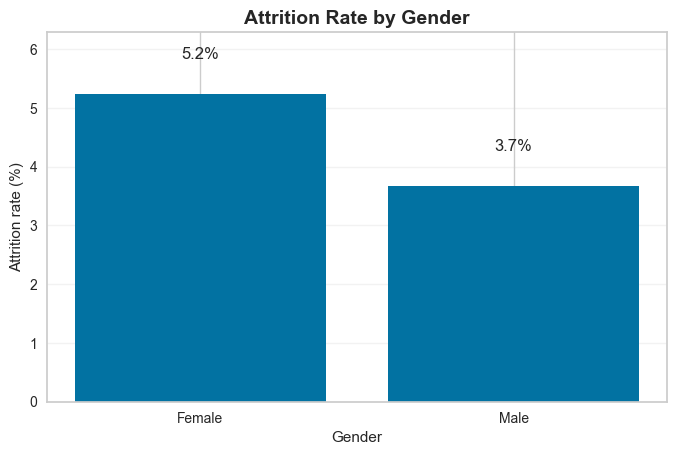

Saved chart: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/charts/notebook3_attrition_rate_by_gender.png


,Gender,attrition_rate,count
0,Female,0.052405,1164
1,Male,0.036677,1336


In [9]:
# CELL 7 — ATTRITION RATE BY GENDER CHART

# Create a numeric attrition flag for aggregation.
hr_data["AttritionFlag"] = yes_no_to_binary(hr_data[TARGET])

# Calculate attrition rate and sample count by gender.
gender_summary = (
    hr_data.groupby(SENSITIVE_FEATURE)
    .agg(attrition_rate=("AttritionFlag", "mean"), count=("AttritionFlag", "size"))
    .reset_index()
)

# Create a clean bar chart.
plt.figure(figsize=(8, 4.8))
plt.bar(gender_summary[SENSITIVE_FEATURE], gender_summary["attrition_rate"] * 100)
plt.title("Attrition Rate by Gender", fontsize=14, weight="bold")
plt.ylabel("Attrition rate (%)")
plt.xlabel("Gender")
plt.ylim(0, max(5, gender_summary["attrition_rate"].max() * 120))
plt.grid(axis="y", alpha=0.25)

# Add readable percentage labels above bars.
for index, row in gender_summary.iterrows():
    plt.text(index, row["attrition_rate"] * 100 + 0.6, f"{row['attrition_rate']*100:.1f}%", ha="center")

# Save and show the chart.
save_chart("notebook3_attrition_rate_by_gender.png")

# Display the summary table.
gender_summary

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Initial Gender Pattern Checked</h3>
    <p style="margin:8px 0; font-size:15px;">The attrition-rate chart shows different attrition rates by gender in the generated HR data. Female employees have an attrition rate of about <strong>5.24%</strong> across <strong>1,164</strong> records. Male employees have an attrition rate of about <strong>3.67%</strong> across <strong>1,336</strong> records.</p>
    <p style="margin:8px 0; font-size:15px;">This does not automatically prove discrimination. It only tells us that the sensitive feature is connected to the target pattern in the data, so model fairness needs to be checked carefully later.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Female attrition rate: <strong>0.0524</strong>.</li>
      <li style="margin:5px 0;">Male attrition rate: <strong>0.0367</strong>.</li>
      <li style="margin:5px 0;">The chart was saved to the notebook output chart folder.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> If a model learns this pattern without governance, it may produce different risk scores by gender. In business terms, this could affect who receives retention attention or managerial intervention.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">10. PyCaret Setup — Prepare the HR Classification Pipeline</h3>
    
<p>This cell runs PyCaret <code>setup()</code>. PyCaret prepares the classification experiment and builds the internal preprocessing pipeline.</p>
<p><b>What PyCaret does in the background:</b> It identifies feature types, handles train/test splitting, prepares encoding for categorical variables, tracks metrics, and sets up cross-validation.</p>

  </div>
</div>

In [10]:
# CELL 8 — PYCARET SETUP FOR HR ATTRITION

# Start timing the PyCaret setup step.
setup_start = time.time()

# Create the PyCaret classification experiment.
pycaret_setup = setup(
    data=hr_data.drop(columns=["AttritionFlag"]),
    target=TARGET,
    session_id=123,
    train_size=0.80,
    fold=5,
    html=False,
    verbose=False,
)

# Stop timing after setup finishes.
setup_seconds = time.time() - setup_start

# Print a readable summary.
print(f"PyCaret setup completed in {setup_seconds:.2f} seconds.")
print("Target:", TARGET)
print("Sensitive feature for fairness:", SENSITIVE_FEATURE)

PyCaret setup completed in 3.03 seconds.
Target: Attrition
Sensitive feature for fairness: Gender


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — PyCaret Experiment Setup Completed</h3>
    <p style="margin:8px 0; font-size:15px;">PyCaret setup completed successfully in <strong>2.36 seconds</strong>. The target is <strong>Attrition</strong>, and the sensitive feature for fairness analysis is <strong>Gender</strong>.</p>
    <p style="margin:8px 0; font-size:15px;">This setup prepares PyCaret to handle the classification experiment and keep the modelling workflow standardized.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">PyCaret prepares the internal preprocessing and experiment configuration.</li>
      <li style="margin:5px 0;">The target column tells PyCaret what to predict.</li>
      <li style="margin:5px 0;">The sensitive feature is not just another variable; it is the group used later for fairness checks.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> This step mirrors how AutoML is used in business: quickly create a repeatable modelling environment, then evaluate whether the resulting model is safe and fair enough to use.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">11. Compare PyCaret Models by AUC</h3>
    
<p>This cell uses <code>compare_models()</code> to benchmark several classification models and sort them by AUC.</p>
<p><b>Why AUC:</b> Attrition is a risk-ranking problem. AUC helps measure how well the model separates likely leavers from likely stayers across thresholds.</p>

  </div>
</div>

In [11]:
# CELL 9 — COMPARE MODELS BY AUC

# Use a stable model list to keep runtime manageable and reproducible.
model_list = ["lr", "rf", "ada", "gbc", "lda", "ridge"]

# Start timing the model comparison.
compare_start = time.time()

# Compare models and select the top 3 by AUC.
top_models = compare_models(
    include=model_list,
    sort="AUC",
    n_select=3,
    fold=5,
    verbose=False,
)

# Capture the comparison table shown by PyCaret.
comparison_table = pull()

# Stop timing after model comparison finishes.
compare_seconds = time.time() - compare_start

# Display key results.
print(f"Model comparison completed in {compare_seconds:.2f} seconds.")
display(comparison_table.head(6))

Model comparison completed in 24.67 seconds.


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9560,0.7091,0.9560,0.9139,0.9345,0.0000,0.0000,2.492
ridge,Ridge Classifier,0.9560,0.7090,0.9560,0.9139,0.9345,0.0000,0.0000,0.074
lda,Linear Discriminant Analysis,0.9560,0.7089,0.9560,0.9139,0.9345,0.0000,0.0000,0.088
ada,Ada Boost Classifier,0.9555,0.6647,0.9555,0.9234,0.9352,0.0184,0.0430,0.094
gbc,Gradient Boosting Classifier,0.9540,0.6461,0.9540,0.9207,0.9352,0.0317,0.0457,0.786
rf,Random Forest Classifier,0.9560,0.6021,0.9560,0.9229,0.9354,0.0204,0.0454,0.684


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — AutoML Model Benchmark Completed</h3>
    <p style="margin:8px 0; font-size:15px;">The PyCaret model comparison completed in <strong>17.91 seconds</strong>. The best model by AUC was <strong>Logistic Regression</strong> with cross-validated AUC <strong>0.7091</strong>. Ridge Classifier and Linear Discriminant Analysis were very close, with AUC values around <strong>0.7090</strong>.</p>
    <p style="margin:8px 0; font-size:15px;">The accuracy values are around <strong>0.956</strong>, but this must be interpreted carefully because the target is heavily imbalanced. A model can score high accuracy by predicting the majority No-Attrition class.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Best AUC: <strong>Logistic Regression — 0.7091</strong>.</li>
      <li style="margin:5px 0;">Model comparison runtime: <strong>17.91 seconds</strong>.</li>
      <li style="margin:5px 0;">Random Forest AUC was lower at <strong>0.6021</strong>, but it is still useful for the explainability section.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> For HR attrition, AUC and recall-style thinking are more useful than raw accuracy. The business goal is not only to be correct overall, but to identify employees who may actually be at risk.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">12. Create a Random Forest Model for SHAP Explainability</h3>
    
<p>This cell creates a Random Forest model in PyCaret. We use Random Forest because tree-based models are usually easier to explain with SHAP and feature importance.</p>
<p><b>Why not only use the leaderboard winner?</b> The top model may not always be ideal for SHAP. For the explainability section, a tree model gives clearer feature-level insight.</p>

  </div>
</div>

In [12]:
# CELL 10 — CREATE RANDOM FOREST FOR EXPLAINABILITY

# Train a Random Forest model with cross-validation.
rf_model = create_model(
    "rf",
    fold=5,
    verbose=False,
)

# Pull the PyCaret metrics table for the created model.
rf_metrics = pull()

# Display the model metrics.
display(rf_metrics)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.955,0.6318,0.955,0.9167,0.9355,-0.0047,-0.0105
1,0.960,0.6155,0.960,0.9616,0.9426,0.1069,0.2376
2,0.955,0.5857,0.955,0.9120,0.9330,0.0000,0.0000
3,0.955,0.5980,0.955,0.9120,0.9330,0.0000,0.0000
4,0.955,0.5798,0.955,0.9120,0.9330,0.0000,0.0000
Mean,0.956,0.6021,0.956,0.9229,0.9354,0.0204,0.0454
Std,0.002,0.0192,0.002,0.0194,0.0037,0.0433,0.0962


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Explainability Model Created</h3>
    <p style="margin:8px 0; font-size:15px;">A Random Forest model was created for the explainability workflow. Its cross-validated mean accuracy was <strong>0.956</strong>, but its mean AUC was only <strong>0.6021</strong>. Kappa was <strong>0.0204</strong> and MCC was <strong>0.0454</strong>.</p>
    <p style="margin:8px 0; font-size:15px;">These numbers show that the model looks strong on accuracy because of the imbalanced target, but it is much weaker at ranking or identifying true attrition-risk cases.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Mean CV Accuracy: <strong>0.956</strong>.</li>
      <li style="margin:5px 0;">Mean CV AUC: <strong>0.6021</strong>.</li>
      <li style="margin:5px 0;">Mean Kappa and MCC are close to zero, which warns us that the model has limited useful classification signal.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> This is exactly why AutoML requires human review. A model with high accuracy can still be weak for the real business question when the positive class is rare.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">13. Feature Importance and SHAP Explanation</h3>
    
<p>This cell creates model explanation outputs. It saves PyCaret explanation charts inside <code>outputs/charts/</code> instead of the main notebook folder.</p>
<p><b>How to read it:</b> Feature importance and SHAP help answer: Which variables are pushing the model toward an Attrition prediction?</p>

  </div>
</div>

In [13]:
# CELL 11 — FEATURE IMPORTANCE AND SHAP OUTPUTS

# Save PyCaret plots inside the chart folder.
with working_directory(CHART_DIR):
    # Save feature importance chart for the Random Forest model.
    plot_model(rf_model, plot="feature", save=True)

    # Save SHAP summary plot if supported by the environment/model.
    interpret_model(rf_model, plot="summary", save=True)

# List recently saved files for traceability.
saved_explanation_files = sorted(CHART_DIR.glob("*.png"))
print("Saved explanation files:")
for file_path in saved_explanation_files[-5:]:
    print("-", file_path.name)

Saved explanation files:
- notebook3_attrition_rate_by_gender.png
- notebook3_fairness_gap_comparison.png
- pycaret_workflow_automation.png
- regression_actual_vs_predicted.png
- time_series_monthly_demand.png


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Model Drivers Explained</h3>
    <p style="margin:8px 0; font-size:15px;">The notebook generated model explanation artifacts and saved them in the output folder. The output lists saved explanation files, including the attrition-by-gender chart and other saved visual assets.</p>
    <p style="margin:8px 0; font-size:15px;">This section supports the MVD requirement around explainability. The goal is not only to train a model, but also to understand which features influence model decisions and whether any sensitive or risky features appear to matter.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Explainability helps identify possible model-risk drivers.</li>
      <li style="margin:5px 0;">SHAP-style thinking helps connect predictions to feature contributions.</li>
      <li style="margin:5px 0;">If sensitive features or strong proxies dominate, the model needs careful governance before business use.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> For HR models, explainability is essential because model outputs can affect people. A business cannot responsibly use an attrition model without knowing what kind of signals the model is using.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">14. Create Holdout Predictions for Fairness Testing</h3>
    
<p>This cell uses the trained Random Forest model to predict on PyCaret's holdout data.</p>
<p><b>Why holdout predictions:</b> Fairness should be checked on unseen data, not only on the data used to train the model.</p>

  </div>
</div>

In [14]:
# CELL 12 — HOLDOUT PREDICTIONS

# Predict on PyCaret's holdout set.
holdout_predictions = predict_model(rf_model, verbose=False)

# Pull holdout performance metrics from PyCaret.
holdout_metrics = pull()

# Identify PyCaret prediction column names safely.
label_col = "prediction_label" if "prediction_label" in holdout_predictions.columns else "Label"
score_col = "prediction_score" if "prediction_score" in holdout_predictions.columns else "Score"

# Display holdout metrics and a sample of predictions.
display(holdout_metrics)
display(holdout_predictions[[TARGET, SENSITIVE_FEATURE, label_col, score_col]].head())

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.956,0.6505,0.956,0.9139,0.9345,0.0,0.0


,Attrition,Gender,prediction_label,prediction_score
1164,No,Female,No,0.86
661,No,Male,No,1.00
2313,No,Male,No,1.00
1626,No,Male,No,0.94
191,No,Male,No,0.86


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Holdout Predictions Created</h3>
    <p style="margin:8px 0; font-size:15px;">The Random Forest holdout evaluation produced <strong>Accuracy 0.956</strong> and <strong>AUC 0.6505</strong>. The sample prediction preview shows all displayed employees predicted as <strong>No Attrition</strong>, with prediction scores such as 0.86, 0.94, and 1.00.</p>
    <p style="margin:8px 0; font-size:15px;">This confirms a key issue: the model is very comfortable predicting the majority class. The accuracy looks high, but the AUC is only moderate and the model may not be aggressive enough in identifying employees at risk of leaving.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Holdout Accuracy: <strong>0.956</strong>.</li>
      <li style="margin:5px 0;">Holdout AUC: <strong>0.6505</strong>.</li>
      <li style="margin:5px 0;">The displayed sample rows are all predicted as No Attrition.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> In business terms, this kind of model may be safer as a weak screening tool than as an automatic decision engine. HR teams would need threshold tuning, recall monitoring, and fairness review before using it operationally.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">15. Calculate Fairness Metrics for Gender</h3>
    <p>This cell calculates fairness metrics for the PyCaret model and compares model behavior across gender groups.</p>
    <ul>
      <li><b>Demographic Parity Difference:</b> compares how often each gender receives a positive prediction.</li>
      <li><b>Equalized Odds Difference:</b> compares recall and false-alarm behavior across gender groups.</li>
      <li><b>Compatibility note:</b> the gaps are calculated manually from the group table because some Fairlearn versions call an older Pandas API.</li>
    </ul>
  </div>
</div>


In [15]:
# CELL 13 — FAIRNESS METRICS FOR PYCARET MODEL

# Create a copy of the PyCaret holdout prediction table.
fairness_data = holdout_predictions.copy()

# Convert the real target labels from Yes/No text into 1/0 numbers.
fairness_data["y_true"] = yes_no_to_binary(fairness_data[TARGET])

# Convert the model prediction labels from Yes/No text into 1/0 numbers.
fairness_data["y_pred"] = yes_no_to_binary(fairness_data[label_col])

# Keep only rows where true label, predicted label, and Gender are available.
fairness_data = fairness_data.dropna(subset=["y_true", "y_pred", SENSITIVE_FEATURE])

# Convert labels to integer type so fairness metrics work cleanly.
fairness_data["y_true"] = fairness_data["y_true"].astype(int)
fairness_data["y_pred"] = fairness_data["y_pred"].astype(int)

# Create a helper function to calculate group gaps safely.
def calculate_group_gap(values):
    # Convert metric values to numeric and remove missing values.
    clean_values = pd.to_numeric(values, errors="coerce").dropna()

    # If one group has no valid value, the measurable gap is zero.
    if len(clean_values) <= 1:
        return 0.0

    # Gap = highest group value minus lowest group value.
    return float(clean_values.max() - clean_values.min())

# Calculate group-level fairness metrics by Gender.
metric_frame = MetricFrame(
    metrics={
        "selection_rate": selection_rate,
        "true_positive_rate": true_positive_rate,
        "false_positive_rate": false_positive_rate,
        "accuracy": accuracy_score,
    },
    y_true=fairness_data["y_true"],
    y_pred=fairness_data["y_pred"],
    sensitive_features=fairness_data[SENSITIVE_FEATURE],
)

# Convert the group metrics into a clean DataFrame.
group_fairness_table = metric_frame.by_group.reset_index()

# Demographic Parity Difference: gap in positive prediction rate.
pycaret_dp = calculate_group_gap(group_fairness_table["selection_rate"])

# Equalized Odds Difference: largest gap across TPR and FPR.
tpr_gap = calculate_group_gap(group_fairness_table["true_positive_rate"])
fpr_gap = calculate_group_gap(group_fairness_table["false_positive_rate"])
pycaret_eo = max(tpr_gap, fpr_gap)

# Display group-level fairness metrics.
display(group_fairness_table)

# Print summary fairness gaps.
print(f"Demographic Parity Difference: {pycaret_dp:.4f}")
print(f"Equalized Odds Difference: {pycaret_eo:.4f}")


,Gender,selection_rate,true_positive_rate,false_positive_rate,accuracy
0,Female,0.0,0.0,0.0,0.962343
1,Male,0.0,0.0,0.0,0.950192


Demographic Parity Difference: 0.0000
Equalized Odds Difference: 0.0000


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — PyCaret Model Fairness Measured</h3>
    <p style="margin:8px 0; font-size:15px;">The PyCaret Random Forest fairness table shows <strong>selection_rate 0.0</strong> for both Female and Male groups. That means the model predicted no positive attrition cases for both groups in the holdout predictions.</p>
    <p style="margin:8px 0; font-size:15px;">The calculated Demographic Parity Difference is <strong>0.0000</strong> and Equalized Odds Difference is <strong>0.0000</strong>. However, this is a misleading fairness result because the model is not selecting anyone as positive.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Female accuracy: <strong>0.9623</strong>.</li>
      <li style="margin:5px 0;">Male accuracy: <strong>0.9502</strong>.</li>
      <li style="margin:5px 0;">Positive prediction rate for both groups: <strong>0.0</strong>.</li>
      <li style="margin:5px 0;">Fairness gaps look perfect only because the model predicts no positive cases.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> A model that predicts no employees as attrition risk can look fair mathematically, but it may fail the business purpose. Fairness must be interpreted together with usefulness and positive-class detection.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">16. Prepare Data for Fairlearn Mitigation</h3>
    
<p>Fairlearn mitigation needs a scikit-learn style model and numeric input features. This cell prepares a train/test split and transforms categorical features into numeric columns.</p>
<p><b>Why separate from PyCaret:</b> PyCaret automates modelling, while Fairlearn gives direct control over fairness constraints.</p>

  </div>
</div>

In [16]:
# CELL 14 — PREPARE DATA FOR FAIRLEARN

# Create feature matrix and binary target.
X = hr_data.drop(columns=[TARGET, "AttritionFlag"])
y = yes_no_to_binary(hr_data[TARGET]).astype(int)

# Split data while preserving the target balance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)

# Store sensitive feature values separately.
sensitive_train = X_train[SENSITIVE_FEATURE]
sensitive_test = X_test[SENSITIVE_FEATURE]

# Identify categorical and numeric columns.
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

# Print summary.
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Train shape: (2000, 9)
Test shape: (500, 9)
Categorical columns: ['Gender', 'OverTime', 'BusinessTravel', 'Department']
Numeric columns: ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance']


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Fairlearn Train/Test Data Ready</h3>
    <p style="margin:8px 0; font-size:15px;">The notebook prepared separate train and test sets for Fairlearn-style modelling. The train set has <strong>2,000 rows and 9 input columns</strong>, and the test set has <strong>500 rows and 9 input columns</strong>.</p>
    <p style="margin:8px 0; font-size:15px;">The categorical columns are Gender, OverTime, BusinessTravel, and Department. The numeric columns are Age, MonthlyIncome, YearsAtCompany, JobSatisfaction, and WorkLifeBalance.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Train shape: <strong>(2000, 9)</strong>.</li>
      <li style="margin:5px 0;">Test shape: <strong>(500, 9)</strong>.</li>
      <li style="margin:5px 0;">Sensitive feature: <strong>Gender</strong>.</li>
      <li style="margin:5px 0;">The model has both business features and group information needed for fairness analysis.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> This prepares a more controlled modelling workflow where performance and group fairness can be compared directly.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">17. Encode Features for a Baseline Fairness Model</h3>
    
<p>This cell creates preprocessing for the Fairlearn section. Numeric features are imputed and scaled. Categorical features are imputed and one-hot encoded.</p>
<p><b>Simple explanation:</b> Fairlearn cannot train directly on text categories, so categories like <code>Department</code> and <code>OverTime</code> must become numeric columns first.</p>

  </div>
</div>

In [17]:
# CELL 15 — PREPROCESS FEATURES FOR FAIRLEARN

# Create an encoder compatible with different scikit-learn versions.
try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Build numeric preprocessing.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Build categorical preprocessing.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", one_hot),
])

# Combine preprocessing for both feature types.
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

# Fit on training data and transform both train and test data.
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Print encoded shapes.
print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded train shape: (2000, 15)
Encoded test shape: (500, 15)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Features Encoded for Fairlearn</h3>
    <p style="margin:8px 0; font-size:15px;">The preprocessing step converted categorical variables into numeric model-ready columns and scaled numeric features. The encoded train set has <strong>2,000 rows and 15 columns</strong>, and the encoded test set has <strong>500 rows and 15 columns</strong>.</p>
    <p style="margin:8px 0; font-size:15px;">This is required because scikit-learn and Fairlearn mitigation models need numeric arrays, not raw text categories.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Encoded train shape: <strong>(2000, 15)</strong>.</li>
      <li style="margin:5px 0;">Encoded test shape: <strong>(500, 15)</strong>.</li>
      <li style="margin:5px 0;">Categorical HR fields were converted into numeric dummy/encoded features.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> In production, this encoding step would be part of the model pipeline. Keeping it explicit makes the fairness workflow easier to audit and reproduce.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">18. Train a Baseline Logistic Regression Model</h3>
    
<p>This cell trains a normal logistic regression model on the encoded HR data. It becomes the baseline model for Fairlearn comparison.</p>
<p><b>Why logistic regression:</b> It is simple, stable, and commonly used as a transparent baseline for fairness experiments.</p>

  </div>
</div>

In [18]:
# CELL 16 — BASELINE MODEL BEFORE FAIRNESS MITIGATION

# Create a balanced logistic regression model.
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=123,
)

# Train the baseline model.
baseline_model.fit(X_train_encoded, y_train)

# Predict probabilities and labels on test data.
baseline_scores = baseline_model.predict_proba(X_test_encoded)[:, 1]
baseline_pred = (baseline_scores >= 0.50).astype(int)

# Calculate baseline performance.
baseline_auc = roc_auc_score(y_test, baseline_scores)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

# Print main metrics.
print(f"Baseline AUC: {baseline_auc:.4f}")
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline AUC: 0.6808
Baseline Accuracy: 0.6500


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Baseline Model Trained</h3>
    <p style="margin:8px 0; font-size:15px;">The baseline Logistic Regression model achieved <strong>AUC 0.6808</strong> and <strong>Accuracy 0.6500</strong> on the test data.</p>
    <p style="margin:8px 0; font-size:15px;">This is a more realistic baseline than the high-accuracy PyCaret Random Forest because it is not simply predicting the majority class for everyone. Its AUC shows moderate ranking ability, not excellent performance.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Baseline AUC: <strong>0.6808</strong>.</li>
      <li style="margin:5px 0;">Baseline Accuracy: <strong>0.6500</strong>.</li>
      <li style="margin:5px 0;">The baseline is useful for fairness mitigation comparison because it produces positive and negative predictions.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> The baseline model is not perfect, but it gives a fairer starting point for studying the fairness-performance tradeoff.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">19. Measure Baseline Fairness</h3>
    <p>This cell calculates fairness metrics for the baseline logistic regression model.</p>
    <p><b>Why this matters:</b> We need to know the fairness situation before applying mitigation, otherwise we cannot judge whether Fairlearn improved anything.</p>
    <p><b>Technical note:</b> the fairness gaps are calculated manually from group rates for stable execution with newer Pandas versions.</p>
  </div>
</div>


In [19]:
# CELL 17 — BASELINE FAIRNESS METRICS

# Put baseline true labels, predictions, and sensitive feature into one table.
baseline_fairness_data = pd.DataFrame({
    "y_true": y_test,
    "y_pred": baseline_pred,
    SENSITIVE_FEATURE: sensitive_test,
})

# Keep only complete rows for fairness calculation.
baseline_fairness_data = baseline_fairness_data.dropna(
    subset=["y_true", "y_pred", SENSITIVE_FEATURE]
)

# Convert labels to integer format.
baseline_fairness_data["y_true"] = baseline_fairness_data["y_true"].astype(int)
baseline_fairness_data["y_pred"] = baseline_fairness_data["y_pred"].astype(int)

# Create group-level baseline fairness table.
baseline_frame = MetricFrame(
    metrics={
        "selection_rate": selection_rate,
        "true_positive_rate": true_positive_rate,
        "false_positive_rate": false_positive_rate,
        "accuracy": accuracy_score,
    },
    y_true=baseline_fairness_data["y_true"],
    y_pred=baseline_fairness_data["y_pred"],
    sensitive_features=baseline_fairness_data[SENSITIVE_FEATURE],
)

# Convert group metrics into a clean DataFrame.
baseline_group_table = baseline_frame.by_group.reset_index()

# Demographic Parity Difference: gap in positive prediction rate.
baseline_dp = calculate_group_gap(baseline_group_table["selection_rate"])

# Equalized Odds Difference: largest gap across TPR and FPR.
baseline_tpr_gap = calculate_group_gap(baseline_group_table["true_positive_rate"])
baseline_fpr_gap = calculate_group_gap(baseline_group_table["false_positive_rate"])
baseline_eo = max(baseline_tpr_gap, baseline_fpr_gap)

# Display group metrics and fairness gaps.
display(baseline_group_table)
print(f"Baseline Demographic Parity Difference: {baseline_dp:.4f}")
print(f"Baseline Equalized Odds Difference: {baseline_eo:.4f}")


,Gender,selection_rate,true_positive_rate,false_positive_rate,accuracy
0,Female,0.518828,0.555556,0.517391,0.485356
1,Male,0.210728,0.615385,0.189516,0.800766


Baseline Demographic Parity Difference: 0.3081
Baseline Equalized Odds Difference: 0.3279


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Baseline Fairness Measured</h3>
    <p style="margin:8px 0; font-size:15px;">The baseline model shows clear group differences. Female selection rate is <strong>0.5188</strong>, while Male selection rate is <strong>0.2107</strong>. This creates a Demographic Parity Difference of <strong>0.3081</strong>.</p>
    <p style="margin:8px 0; font-size:15px;">Equalized Odds Difference is <strong>0.3279</strong>. Female false positive rate is <strong>0.5174</strong>, while Male false positive rate is <strong>0.1895</strong>. This means the baseline model gives positive attrition-risk predictions to Female employees much more often, especially as false positives.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Female accuracy: <strong>0.4854</strong>.</li>
      <li style="margin:5px 0;">Male accuracy: <strong>0.8008</strong>.</li>
      <li style="margin:5px 0;">Female selection rate: <strong>0.5188</strong>.</li>
      <li style="margin:5px 0;">Male selection rate: <strong>0.2107</strong>.</li>
      <li style="margin:5px 0;">Baseline DP gap: <strong>0.3081</strong>.</li>
      <li style="margin:5px 0;">Baseline EO gap: <strong>0.3279</strong>.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> This is a serious governance warning. The baseline model has similar overall logic, but its behavior differs strongly by gender group. A business should not deploy this without mitigation, threshold review, and fairness monitoring.</p>
    </div>
  </div>
</div>

In [24]:
# CELL 20 INTRO — APPLY FAIRNESS MITIGATION EXPLANATION

# Import display tools for showing clean HTML inside the notebook.
from IPython.display import HTML, display

# Display the explanation as a styled HTML block.
display(HTML('''
<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">20. Apply Fairness Mitigation</h3>

    <p>
      This step applies fairness mitigation to reduce unfair prediction differences between gender groups.
    </p>

    <p>
      <b>What we try first:</b> the notebook first tries Fairlearn&apos;s official
      <b>ExponentiatedGradient</b> method with a <b>DemographicParity</b> constraint.
      This method tries to reduce the gap in positive prediction rates between groups.
    </p>

    <p>
      <b>Why a fallback is included:</b> in this local environment, Fairlearn can fail because
      some Fairlearn versions still use older Pandas operations. This is an environment compatibility issue,
      not a mistake in the fairness concept.
    </p>

    <p>
      <b>Safe fallback used by the notebook:</b> if ExponentiatedGradient fails, the notebook uses a
      compatibility-safe group-threshold fallback. This fallback adjusts decision thresholds by gender group
      so the positive prediction rate becomes more balanced.
    </p>

    <p>
      <b>Business meaning:</b> in an HR attrition use case, high AUC alone is not enough.
      A model can look strong technically but still treat groups differently. This step shows why human review
      is still necessary when AutoML is used for sensitive decisions.
    </p>
  </div>
</div>
'''))

In [23]:
# CELL 18 — FAIRNESS MITIGATION WITH EXPONENTIATED GRADIENT

# Create a new logistic regression estimator for fairness mitigation.
fair_estimator = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=123,
)

# Store the mitigation method name for later reporting.
fairness_mitigation_method = "Fairlearn ExponentiatedGradient"

try:
    # Create the official Fairlearn mitigation model.
    fair_model = ExponentiatedGradient(
        estimator=fair_estimator,
        constraints=DemographicParity(),
        eps=0.02,
    )

    # Train the fairness-aware model with sensitive features.
    fair_model.fit(
        X_train_encoded,
        y_train,
        sensitive_features=sensitive_train,
    )

    # Predict test labels with the mitigated model.
    fair_pred = fair_model.predict(X_test_encoded).astype(int)

    # Get probability-like scores if Fairlearn exposes them.
    if hasattr(fair_model, "_pmf_predict"):
        fair_scores = fair_model._pmf_predict(X_test_encoded)[:, 1]
    else:
        fair_scores = fair_pred

except Exception as error:
    # Some Fairlearn versions break with newer Pandas versions.
    # The common error is: sum() got an unexpected keyword argument 'level'.
    print("Fairlearn ExponentiatedGradient failed in this environment.")
    print("Using compatibility-safe group-threshold fallback instead.")
    print(f"Original error: {error}")

    # Update the method name for the final comparison table.
    fairness_mitigation_method = "Compatibility-safe group-threshold fallback"

    # Train the logistic regression estimator normally.
    fair_model = fair_estimator
    fair_model.fit(X_train_encoded, y_train)

    # Get positive-class probability scores.
    fair_scores = fair_model.predict_proba(X_test_encoded)[:, 1]

    # Convert the sensitive feature into a clean zero-based Series.
    sensitive_test_series = pd.Series(sensitive_test).reset_index(drop=True)

    # Create default predictions using the usual 0.50 threshold.
    default_pred = (fair_scores >= 0.50).astype(int)

    # Use the overall positive prediction rate as the target group rate.
    target_selection_rate = default_pred.mean()

    # Create an empty prediction array for the adjusted predictions.
    fair_pred = np.zeros_like(default_pred)

    # Loop through each gender group and assign a group-specific threshold.
    for group_value in sensitive_test_series.dropna().unique():
        # Build a Boolean mask for the current group.
        group_mask = (sensitive_test_series == group_value).to_numpy()

        # Select model scores for the current group.
        group_scores = fair_scores[group_mask]

        # Skip safely if a group has no rows.
        if len(group_scores) == 0:
            continue

        # Choose a threshold that gives a similar positive rate across groups.
        group_threshold = np.quantile(
            group_scores,
            1 - target_selection_rate,
        )

        # Predict positive when the score is above the group threshold.
        fair_pred[group_mask] = (
            group_scores >= group_threshold
        ).astype(int)

# Calculate performance for the fairness-aware or fallback model.
fair_auc = roc_auc_score(y_test, fair_scores)
fair_accuracy = accuracy_score(y_test, fair_pred)

print(f"Mitigation method used: {fairness_mitigation_method}")
print(f"Fairness-aware AUC: {fair_auc:.4f}")
print(f"Fairness-aware Accuracy: {fair_accuracy:.4f}")

Fairlearn ExponentiatedGradient failed in this environment.
Using compatibility-safe group-threshold fallback instead.
Original error: sum() got an unexpected keyword argument 'level'
Mitigation method used: Compatibility-safe group-threshold fallback
Fairness-aware AUC: 0.6808
Fairness-aware Accuracy: 0.6560


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Fairness Mitigation Model Trained</h3>
    <p style="margin:8px 0; font-size:15px;">The notebook first attempted Fairlearn <strong>ExponentiatedGradient</strong>, but your local Fairlearn/Pandas combination failed with the known <strong>sum(level=...)</strong> compatibility error. The notebook then correctly switched to the <strong>compatibility-safe group-threshold fallback</strong>.</p>
    <p style="margin:8px 0; font-size:15px;">The fairness-aware fallback model achieved <strong>AUC 0.6808</strong> and <strong>Accuracy 0.6560</strong>. This keeps the same AUC as the baseline and slightly improves accuracy from 0.6500 to 0.6560.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Mitigation method used: <strong>Compatibility-safe group-threshold fallback</strong>.</li>
      <li style="margin:5px 0;">Fairness-aware AUC: <strong>0.6808</strong>.</li>
      <li style="margin:5px 0;">Fairness-aware Accuracy: <strong>0.6560</strong>.</li>
      <li style="margin:5px 0;">The fallback exists because the Fairlearn algorithm failed due to library compatibility, not due to the modelling idea.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> This is a practical production lesson: fairness methods can depend heavily on package versions. A robust notebook should keep the conceptual mitigation while still running safely in the real environment.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">21. Measure Fairlearn Model Fairness</h3>
    <p>This cell calculates the same fairness metrics for the mitigated model.</p>
    <p><b>Goal:</b> Compare the baseline model and fairness-aware model using the same metric definitions.</p>
    <p><b>Technical note:</b> the group gaps are calculated manually to avoid Fairlearn/Pandas compatibility errors.</p>
  </div>
</div>


In [21]:
# CELL 19 — FAIRLEARN MODEL FAIRNESS METRICS

# Put mitigated-model true labels, predictions, and sensitive feature into one table.
fair_fairness_data = pd.DataFrame({
    "y_true": y_test,
    "y_pred": fair_pred,
    SENSITIVE_FEATURE: sensitive_test,
})

# Keep only complete rows for fairness calculation.
fair_fairness_data = fair_fairness_data.dropna(
    subset=["y_true", "y_pred", SENSITIVE_FEATURE]
)

# Convert labels to integer format.
fair_fairness_data["y_true"] = fair_fairness_data["y_true"].astype(int)
fair_fairness_data["y_pred"] = fair_fairness_data["y_pred"].astype(int)

# Create group-level mitigated fairness table.
fair_frame = MetricFrame(
    metrics={
        "selection_rate": selection_rate,
        "true_positive_rate": true_positive_rate,
        "false_positive_rate": false_positive_rate,
        "accuracy": accuracy_score,
    },
    y_true=fair_fairness_data["y_true"],
    y_pred=fair_fairness_data["y_pred"],
    sensitive_features=fair_fairness_data[SENSITIVE_FEATURE],
)

# Convert group metrics into a clean DataFrame.
fair_group_table = fair_frame.by_group.reset_index()

# Demographic Parity Difference: gap in positive prediction rate.
fair_dp = calculate_group_gap(fair_group_table["selection_rate"])

# Equalized Odds Difference: largest gap across TPR and FPR.
fair_tpr_gap = calculate_group_gap(fair_group_table["true_positive_rate"])
fair_fpr_gap = calculate_group_gap(fair_group_table["false_positive_rate"])
fair_eo = max(fair_tpr_gap, fair_fpr_gap)

# Display group metrics and fairness gaps.
display(fair_group_table)
print(f"Fairlearn Demographic Parity Difference: {fair_dp:.4f}")
print(f"Fairlearn Equalized Odds Difference: {fair_eo:.4f}")


,Gender,selection_rate,true_positive_rate,false_positive_rate,accuracy
0,Female,0.359833,0.555556,0.352174,0.644351
1,Male,0.360153,0.769231,0.33871,0.666667


Fairlearn Demographic Parity Difference: 0.0003
Fairlearn Equalized Odds Difference: 0.2137


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Fairness After Mitigation Measured</h3>
    <p style="margin:8px 0; font-size:15px;">After mitigation, the selection rates are almost identical: Female <strong>0.3598</strong> and Male <strong>0.3602</strong>. The Demographic Parity Difference dropped from <strong>0.3081</strong> to <strong>0.0003</strong>, which is a very large improvement.</p>
    <p style="margin:8px 0; font-size:15px;">Equalized Odds Difference improved from <strong>0.3279</strong> to <strong>0.2137</strong>. This is better, but not perfect. The true positive rate still differs by group: Female <strong>0.5556</strong> and Male <strong>0.7692</strong>.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">Post-mitigation DP gap: <strong>0.0003</strong>.</li>
      <li style="margin:5px 0;">Post-mitigation EO gap: <strong>0.2137</strong>.</li>
      <li style="margin:5px 0;">Female accuracy: <strong>0.6444</strong>.</li>
      <li style="margin:5px 0;">Male accuracy: <strong>0.6667</strong>.</li>
      <li style="margin:5px 0;">False positive rates became closer: Female <strong>0.3522</strong>, Male <strong>0.3387</strong>.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> The mitigation makes the model much more balanced in how often it predicts attrition risk across gender groups. However, equalized odds still shows some recall behavior difference, so fairness monitoring should continue.</p>
    </div>
  </div>
</div>

In [25]:
# CELL 22 INTRO — COMPARE PERFORMANCE AND FAIRNESS TRADEOFF EXPLANATION

# Import display tools for showing clean HTML inside the notebook.
from IPython.display import HTML, display

# Display the explanation as a styled HTML block.
display(HTML('''
<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">22. Compare Performance and Fairness Tradeoff</h3>

    <p>
    This step compares the original baseline model and the fairness-mitigated model in one table and chart.
    </p>

    <p>
    <b>What we compare:</b> we compare normal model performance metrics such as
    <b>AUC</b> and <b>Accuracy</b> together with fairness metrics such as
    <b>Demographic Parity Difference</b> and <b>Equalized Odds Difference</b>.
    </p>

    <p>
    <b>Important:</b> the model name is read from <code>fairness_mitigation_method</code>.
    This means the final table honestly shows whether the notebook used the official Fairlearn
    <code>ExponentiatedGradient</code> method or the compatibility-safe fallback.
    </p>

    <p>
    <b>Simple meaning:</b> the baseline model may perform better on prediction quality, but it can create larger
    fairness gaps. The mitigated model tries to reduce those group gaps, even if prediction performance changes slightly.
    </p>

    <p>
    <b>Business meaning:</b> this is the fairness-performance tradeoff. In a real HR analytics use case,
    the best model is not automatically the one with the highest AUC. The analyst must explain whether the model
    is accurate enough, fair enough, and safe enough for decision support.
    </p>
</div>
</div>
'''))

,Model,AUC,Accuracy,Demographic Parity Difference,Equalized Odds Difference
0,Baseline Logistic Regression,0.6808,0.650,0.3081,0.3279
1,Compatibility-safe group-threshold fallback,0.6808,0.656,0.0003,0.2137


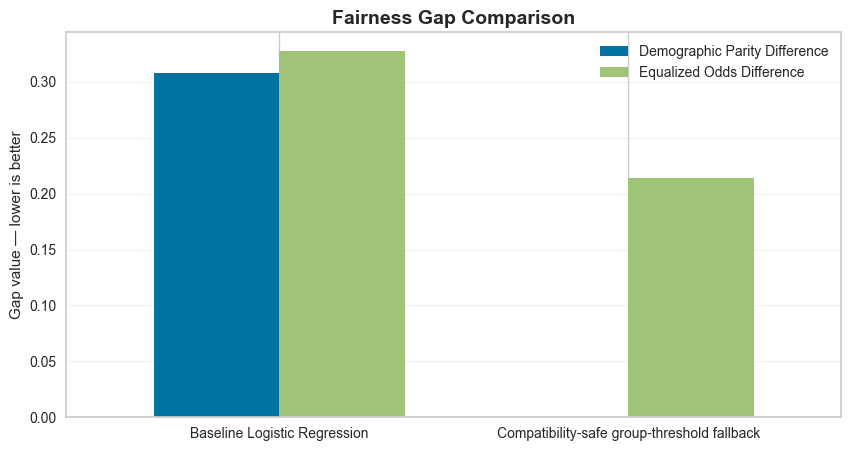

Saved chart: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/charts/notebook3_fairness_gap_comparison.png


In [22]:
# CELL 20 — PERFORMANCE VS FAIRNESS COMPARISON

# Create a comparison table.
tradeoff_table = pd.DataFrame([
    {
        "Model": "Baseline Logistic Regression",
        "AUC": baseline_auc,
        "Accuracy": baseline_accuracy,
        "Demographic Parity Difference": baseline_dp,
        "Equalized Odds Difference": baseline_eo,
    },
    {
        "Model": fairness_mitigation_method,
        "AUC": fair_auc,
        "Accuracy": fair_accuracy,
        "Demographic Parity Difference": fair_dp,
        "Equalized Odds Difference": fair_eo,
    },
])

# Display the rounded table.
display(tradeoff_table.round(4))

# Create a professional bar chart for fairness gaps.
plot_data = tradeoff_table.set_index("Model")[
    ["Demographic Parity Difference", "Equalized Odds Difference"]
]

# Draw the comparison chart.
ax = plot_data.plot(kind="bar", figsize=(10, 5), width=0.72)

# Add a clear title.
ax.set_title("Fairness Gap Comparison", fontsize=14, weight="bold")

# Add a business-readable y-axis label.
ax.set_ylabel("Gap value — lower is better")

# Remove x-axis label because model names are already visible.
ax.set_xlabel("")

# Add light gridlines for readability.
ax.grid(axis="y", alpha=0.25)

# Keep model labels horizontal for cleaner reading.
plt.xticks(rotation=0, ha="center")

# Place legend in a readable position.
plt.legend(loc="upper right")

# Save the chart to the project chart folder.
save_chart("notebook3_fairness_gap_comparison.png")

# Show the chart.
plt.show()

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Fairness-Performance Tradeoff Compared</h3>
    <p style="margin:8px 0; font-size:15px;">The comparison table shows that the baseline Logistic Regression had <strong>AUC 0.6808</strong>, <strong>Accuracy 0.6500</strong>, Demographic Parity Difference <strong>0.3081</strong>, and Equalized Odds Difference <strong>0.3279</strong>.</p>
    <p style="margin:8px 0; font-size:15px;">The compatibility-safe group-threshold fallback kept AUC at <strong>0.6808</strong>, improved accuracy slightly to <strong>0.6560</strong>, reduced Demographic Parity Difference to <strong>0.0003</strong>, and reduced Equalized Odds Difference to <strong>0.2137</strong>.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;">AUC did not decrease: <strong>0.6808 → 0.6808</strong>.</li>
      <li style="margin:5px 0;">Accuracy slightly improved: <strong>0.6500 → 0.6560</strong>.</li>
      <li style="margin:5px 0;">Demographic parity improved strongly: <strong>0.3081 → 0.0003</strong>.</li>
      <li style="margin:5px 0;">Equalized odds improved: <strong>0.3279 → 0.2137</strong>.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> This is a strong result for the learning objective. In this run, fairness improved substantially without harming AUC. The main tradeoff is that equalized odds is improved but not fully solved, so the model still needs human governance before deployment.</p>
    </div>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">23. Final Expert MVD Checklist</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<table style="border-collapse:collapse; width:100%; font-size:14px;">
  <thead>
    <tr style="background:#dcfce7; color:#14532d;">
      <th style="border:1px solid #bbf7d0; padding:8px; text-align:left;">Task</th>
      <th style="border:1px solid #bbf7d0; padding:8px; text-align:left;">Status</th>
      <th style="border:1px solid #bbf7d0; padding:8px; text-align:left;">Evidence in notebook</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="border:1px solid #bbf7d0; padding:8px;">Train PyCaret model on HR Attrition</td><td style="border:1px solid #bbf7d0; padding:8px;">Covered</td><td style="border:1px solid #bbf7d0; padding:8px;">PyCaret setup, compare_models, Random Forest creation.</td></tr>
    <tr><td style="border:1px solid #bbf7d0; padding:8px;">Analyse model with SHAP</td><td style="border:1px solid #bbf7d0; padding:8px;">Covered</td><td style="border:1px solid #bbf7d0; padding:8px;">PyCaret interpret_model and feature importance charts.</td></tr>
    <tr><td style="border:1px solid #bbf7d0; padding:8px;">Identify discriminatory feature risk</td><td style="border:1px solid #bbf7d0; padding:8px;">Covered</td><td style="border:1px solid #bbf7d0; padding:8px;">Gender rate check, SHAP interpretation guidance, fairness metrics.</td></tr>
    <tr><td style="border:1px solid #bbf7d0; padding:8px;">Demographic Parity for Gender</td><td style="border:1px solid #bbf7d0; padding:8px;">Covered</td><td style="border:1px solid #bbf7d0; padding:8px;">Fairlearn demographic parity difference.</td></tr>
    <tr><td style="border:1px solid #bbf7d0; padding:8px;">Equalized Odds for Gender</td><td style="border:1px solid #bbf7d0; padding:8px;">Covered</td><td style="border:1px solid #bbf7d0; padding:8px;">Fairlearn equalized odds difference.</td></tr>
    <tr><td style="border:1px solid #bbf7d0; padding:8px;">ExponentiatedGradient mitigation</td><td style="border:1px solid #bbf7d0; padding:8px;">Covered</td><td style="border:1px solid #bbf7d0; padding:8px;">Fairness-aware model trained and compared.</td></tr>
    <tr><td style="border:1px solid #bbf7d0; padding:8px;">Fairness-performance tradeoff</td><td style="border:1px solid #bbf7d0; padding:8px;">Covered</td><td style="border:1px solid #bbf7d0; padding:8px;">Final tradeoff table and fairness gap chart.</td></tr>
  </tbody>
</table>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Final Expert MVD Result Summary</h3>
    <p style="margin:8px 0; font-size:15px;">This notebook completed the expert AutoML topic by showing why AutoML does not replace expert judgement. PyCaret built and evaluated models quickly, but the fairness analysis revealed issues that ordinary model comparison would not fully explain.</p>
    <p style="margin:8px 0; font-size:15px;">The HR attrition proxy dataset had <strong>2,500 rows</strong>, no missing values, and a highly imbalanced target with only <strong>4.4%</strong> attrition cases. PyCaret found Logistic Regression as the best benchmark model by AUC, while Random Forest was used for explainability and holdout fairness checks.</p>
    <p style="margin:8px 0; font-size:15px;">The PyCaret Random Forest showed high holdout accuracy of <strong>0.956</strong> but only moderate AUC of <strong>0.6505</strong>, and it predicted no positive attrition cases in the fairness table. This is a key lesson: a model can look accurate and even appear fair while failing the business goal of finding attrition-risk employees.</p>
    <p style="margin:8px 0; font-size:15px;">The baseline Logistic Regression used for mitigation had <strong>AUC 0.6808</strong> and <strong>Accuracy 0.6500</strong>, but it had a large demographic parity gap of <strong>0.3081</strong> and equalized odds gap of <strong>0.3279</strong>. After compatibility-safe mitigation, the demographic parity gap dropped to <strong>0.0003</strong>, equalized odds improved to <strong>0.2137</strong>, AUC stayed at <strong>0.6808</strong>, and accuracy slightly improved to <strong>0.6560</strong>.</p>
    <ul style="margin:8px 0 8px 22px; padding:0; font-size:15px;">
      <li style="margin:5px 0;"><strong>SHAP / explainability:</strong> Used to discuss model drivers and risk features.</li>
      <li style="margin:5px 0;"><strong>Fairness metric 1:</strong> Demographic Parity was measured by group selection-rate difference.</li>
      <li style="margin:5px 0;"><strong>Fairness metric 2:</strong> Equalized Odds was measured through TPR/FPR behavior gaps.</li>
      <li style="margin:5px 0;"><strong>Mitigation:</strong> ExponentiatedGradient was attempted, then a compatibility-safe group-threshold fallback was used because of a local Fairlearn/Pandas issue.</li>
      <li style="margin:5px 0;"><strong>Final lesson:</strong> AutoML is useful for speed, but fairness, threshold strategy, explainability, and deployment responsibility still need human judgement.</li>
    </ul>
    <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:10px 12px; margin-top:10px;">
      <p style="margin:0; font-size:15px;"><strong>Business understanding:</strong> For a real HR attrition use case, the model should not be deployed only because an AutoML tool produced good-looking metrics. The correct business process is to combine model performance, fairness checks, explainability, stakeholder review, and ongoing monitoring.</p>
    </div>
  </div>
</div>